# Strategic Retail Analytics: US Superstore Performance

### Project Objective  
To identify profit leakage areas and high-growth opportunities using a hybrid Python–SQL analytical approach.

### Business Context  
Retail organizations often face challenges in balancing revenue growth with profitability due to discounting strategies, regional performance disparities, and product mix inefficiencies.

### Key Goals  
- Analyze sales and profit performance across categories, regions, and time  
- Identify high-performing and underperforming segments  
- Evaluate the impact of discounts on profitability  
- Uncover seasonal trends and demand patterns  

### Expected Outcome  
This analysis delivers actionable insights to support:
- Inventory optimization  
- Pricing and discount strategy improvements  
- Region-specific marketing decisions  

In [4]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 6)

print("Environment Setup Complete.")

Environment Setup Complete.


# 1. Data Ingestion & Schema Standardization
We are standardizing column names (removing spaces) to ensure compatibility with SQL naming conventions and parsing dates at the point of entry.

In [5]:
df = pd.read_csv("Superstore.csv", encoding_errors='ignore', parse_dates=['Order Date', 'Ship Date'])

# Standardize column names for SQL compatibility
df.columns = [col.replace(' ', '_').replace('-', '_') for col in df.columns]

# 1.1 Data Loading & Initial Transformation

In [6]:
# Feature Engineering (Time-based)
df['Order_Year'] = df['Order_Date'].dt.year
df['Order_Month'] = df['Order_Date'].dt.month_name()
df['Order_Month_Val'] = df['Order_Date'].dt.month  # for sorting

df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,Order_Month_Val
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November,11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November,11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October,10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October,10


# 2. Data Quality Assurance

We validate dataset integrity by checking for missing values, duplicates, and overall structure before analysis.

In [7]:
health_check = {
    "Total Records": len(df),
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Timeline": f"{df.Order_Date.min().date()} to {df.Order_Date.max().date()}"
}

health_df = pd.DataFrame(list(health_check.items()), columns=["Metric", "Value"])
health_df

,Metric,Value
0,Total Records,9994
1,Missing Values,0
2,Duplicate Rows,0
3,Timeline,2014-01-03 to 2017-12-30


# 2.1 Data Cleaning Actions

Addressing duplicate records and handling critical missing values identified during quality checks.

In [9]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values (focused)
df = df.dropna(subset=['Sales', 'Profit'])

# Exploratory Data Analysis (EDA)

Analyzing sales, profit, and customer behavior across categories, regions, and time.

# Category Analysis

In [10]:
df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


**Insight:**  
Technology leads in total sales, indicating strong customer demand. However, high sales do not always translate into high profit, suggesting potential margin inefficiencies. This highlights the need to optimize pricing and discount strategies within high-revenue categories.

# Region Analysis

In [11]:
df.groupby('Region')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


**Insight:**  
Sales are concentrated in the West region, indicating stronger market demand. This suggests prioritizing inventory allocation and marketing efforts in this region to maximize revenue growth, while improving performance in lower-performing regions.

# Monthly Trend

In [12]:
monthly_sales = df.groupby('Order_Month_Val')['Sales'].sum()
monthly_sales

Order_Month_Val
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64

**Insight:**  
Sales show clear seasonal patterns with peak performance in specific months, indicating the impact of seasonal demand. This suggests aligning inventory planning and promotional campaigns with high-demand periods to maximize revenue.

# Sub-categories Analysis

In [13]:
nov_office = df[(df['Order_Month'] == 'November') & (df['Category'] == 'Office Supplies')]

nov_office.groupby('Sub_Category')['Quantity'].sum().sort_values(ascending=False)

Sub_Category
Binders       925
Paper         768
Storage       504
Art           425
Appliances    253
Labels        170
Fasteners     158
Envelopes     152
Supplies       97
Name: Quantity, dtype: int64

**Insight:**
Specific sub-categories dominate seasonal demand during November, indicating strong holiday-driven purchasing behavior.

# Technology Category Analysis
Which sub-categories within Technology drive the highest sales and profitability?

In [15]:
df[df['Category'] == 'Technology'].groupby('Sub_Category')[['Sales','Quantity','Profit']].sum().sort_values(by='Sales', ascending=False)

,Sales,Quantity,Profit
Sub_Category,,,
Phones,330007.054,3289,44515.7306
Machines,189238.631,440,3384.7569
Accessories,167380.318,2976,41936.6357
Copiers,149528.030,234,55617.8249


**Insight:**  
Within the Technology category, a few sub-categories dominate sales, indicating concentrated demand. However, variations in profit across sub-categories suggest differences in margin efficiency, highlighting opportunities for product-level optimization.

# Top Profitable States
Which states contribute the most to overall profit?

In [16]:
df.groupby('State')['Profit'].sum().sort_values(ascending=False).head()

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Name: Profit, dtype: float64

***Insight:***
A small number of states contribute a large share of total profit, indicating geographic concentration of profitability.

# Discount Distribution by Segment
Which customer segment receives the highest total discounts?

In [17]:
df.groupby('Segment')['Discount'].sum().sort_values(ascending=False)

Segment
Consumer       820.91
Corporate      477.85
Home Office    262.33
Name: Discount, dtype: float64

**Insight:**  
Higher discounts are concentrated in specific customer segments, which may be negatively impacting overall profitability. This suggests the need to reassess discount strategies to balance customer acquisition with profit margins.

# SQL-Based Analysis Engine

Using SQL to simulate production-level querying and extract advanced business insights.

In [18]:
conn = sqlite3.connect('superstore.db')
df.to_sql('sales', conn, if_exists='replace', index=False)

def run_query(query):
    return pd.read_sql(query, conn)

# Top Categories by Sales (SQL)
Identifying revenue-driving categories using SQL.

In [19]:
run_query("""
SELECT Category, SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC
""")

,Category,Total_Sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


**Insight:**
SQL results confirm that Technology category consistently outperform others, reinforcing earlier findings from Python analysis.

# Average Sales by Region
Which region has the highest average transaction value?

In [20]:
run_query("""
SELECT Region, AVG(Sales) AS Avg_Sales
FROM sales
GROUP BY Region
ORDER BY Avg_Sales DESC
""")

,Region,Avg_Sales
0,South,241.803645
1,East,238.336110
2,West,226.493233
3,Central,215.772661


**Insight:**
Some regions generate higher-value transactions despite lower total volume, indicating differences in customer purchasing behavior.

# Top Profitable States (SQL)

In [21]:
run_query("""
SELECT State, SUM(Profit) AS Total_Profit
FROM sales
GROUP BY State
ORDER BY Total_Profit DESC
LIMIT 3
""")

,State,Total_Profit
0,California,76381.3871
1,New York,74038.5486
2,Washington,33402.6517


**Insight:**
Profitability is concentrated in a few key states, suggesting targeted expansion opportunities.

# Highest Transaction per Region
Identifying the largest sale in each region using window functions.

In [34]:
run_query("""
WITH RankedSales AS (
    SELECT 
        Region, 
        Sales, 
        ROW_NUMBER() OVER (PARTITION BY Region ORDER BY Sales DESC) as rn 
    FROM sales
)
SELECT Region, Sales 
FROM RankedSales 
WHERE rn = 1
ORDER BY Sales DESC;
""")

,Region,Sales
0,South,22638.480
1,Central,17499.950
2,West,13999.960
3,East,11199.968


**Insight:**
Each region has high-value transactions, indicating the presence of premium customers and opportunities for high-ticket sales strategies.

# Visual Insights

Objective:
Analyze sale data to understand:
- Sales performance by region
- Relationship between variables
- Profit distribution across categories

# Sales by Category
Which category generates the highest revenue?

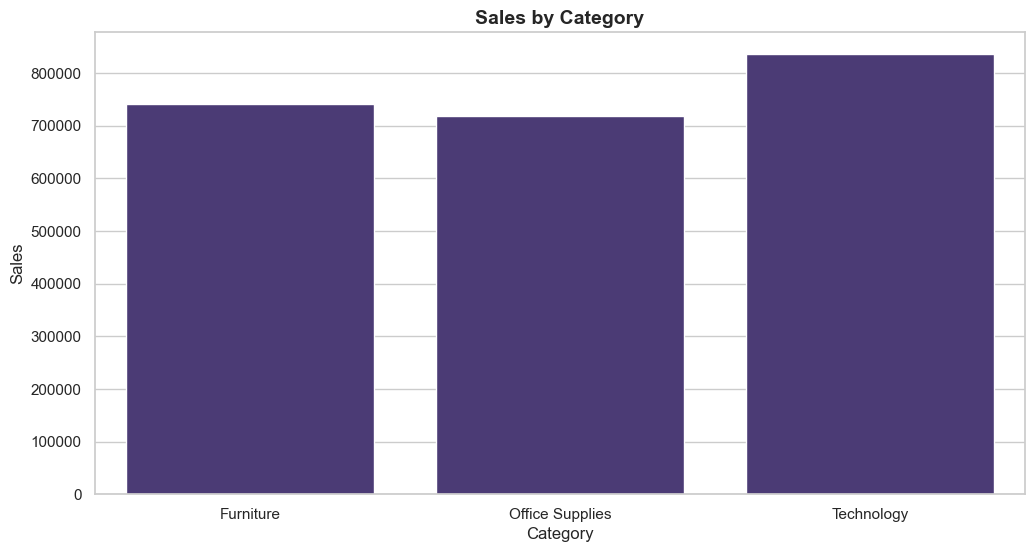

In [36]:
sns.barplot(x='Category', y='Sales', data=df, estimator='sum', errorbar=None)
plt.title("Sales by Category", fontsize=14, weight='bold')
plt.show()

**Insight:**
The leading technology category significantly outperforms others, indicating a strong revenue driver.

# Profit by Region
Which region contributes most to profitability?

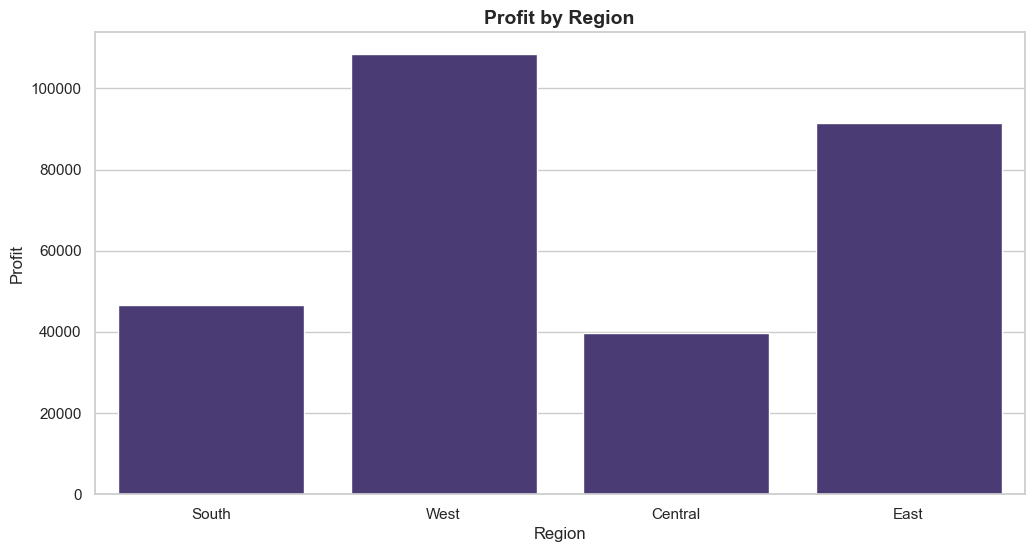

In [37]:
sns.barplot(x='Region', y='Profit', data=df, estimator='sum', errorbar=None)
plt.title("Profit by Region", fontsize=14, weight='bold')
plt.show()

**Insight:**
Profit distribution varies across regions, suggesting the need for region-specific strategies.

# Monthly Sales Trend
How does sales vary across the year?

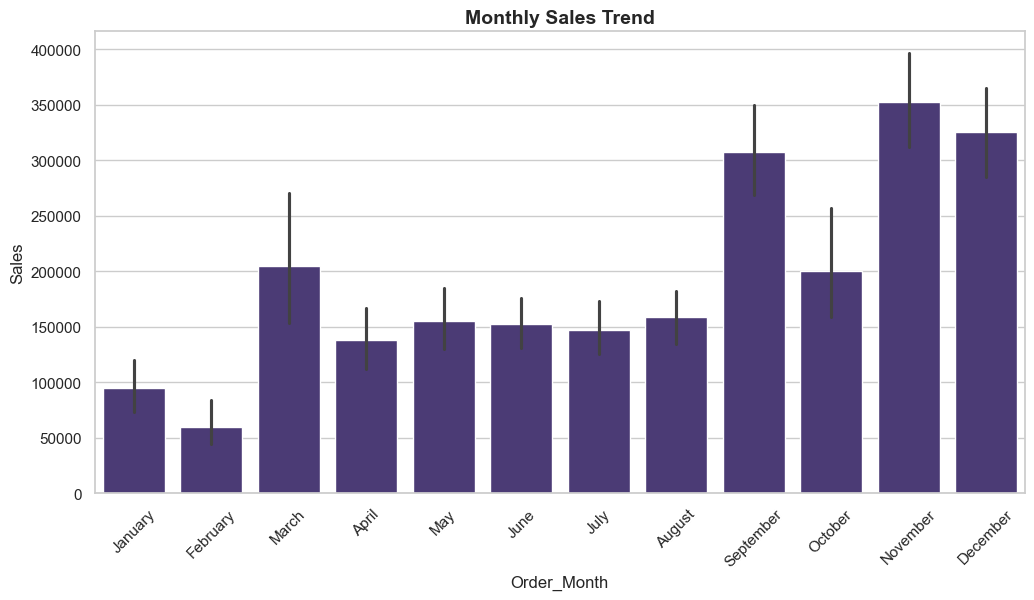

In [38]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

sns.barplot(x='Order_Month', y='Sales', data=df, order=month_order, estimator='sum')
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend", fontsize=14, weight='bold')
plt.show()

**Insight:**
Sales show clear seasonal patterns, with peak months indicating high-demand periods.

***Key Finding:*** Sales peak dramatically in November. This isn't just "holiday shopping"—our data shows a massive spike in Office Supplies (Binders and Paper). We should ensure stock levels are increased by October to meet this recurring demand.

# Sales vs Profit Relationship
Do higher sales always result in higher profit?

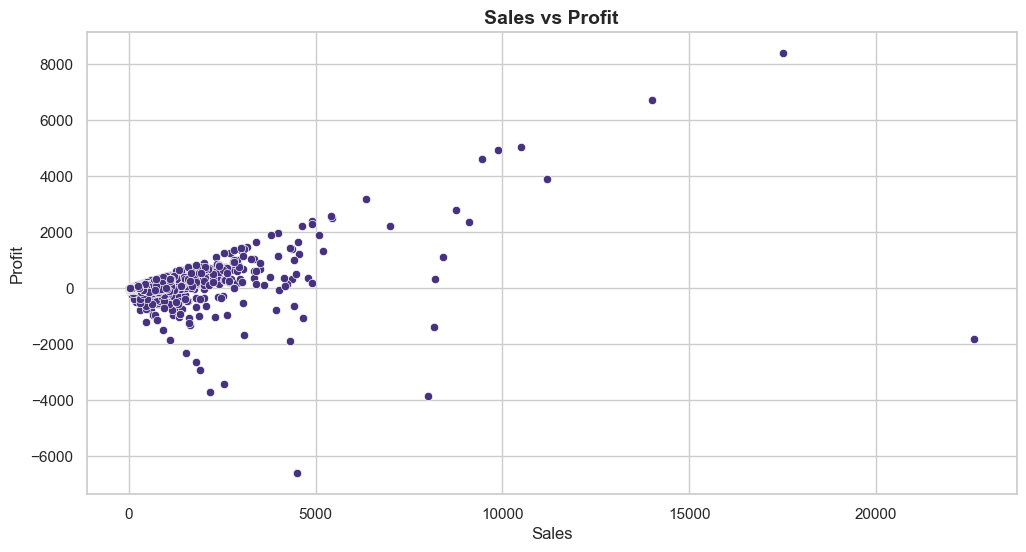

In [39]:
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit", fontsize=14, weight='bold')
plt.show()

**Insight:** Not all high-sales transactions generate high profit, indicating the impact of discounts or cost inefficiencies.

# Impact of Discounts on Profitability
How do discounts affect profit margins?

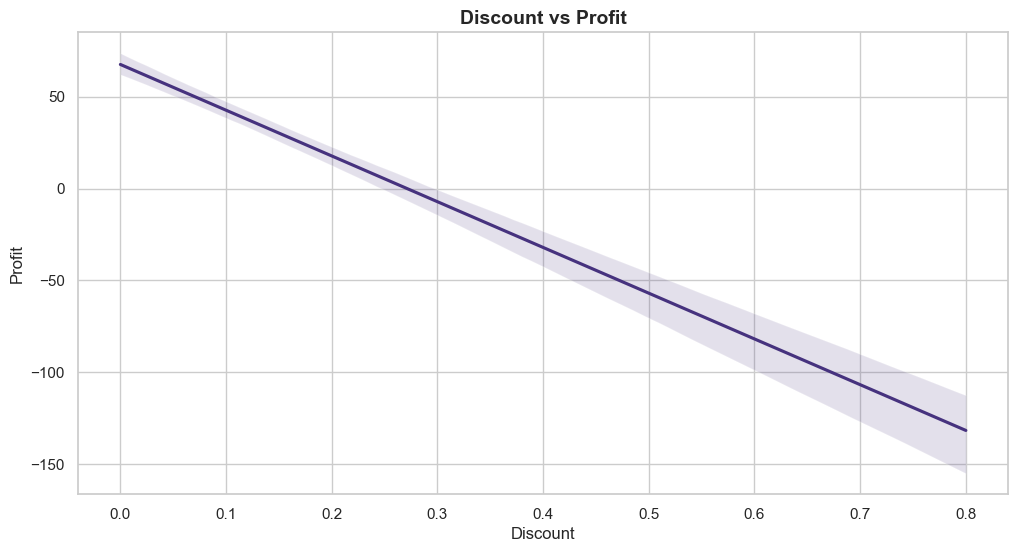

In [43]:
sns.regplot(x='Discount', y='Profit', data=df, scatter=False)
plt.title("Discount vs Profit", fontsize=14, weight='bold')
plt.show()

**Insight:**
Higher discounts are often associated with lower or negative profit, suggesting aggressive discounting may be harming profitability.

***Warning:*** Profit turns negative once discounts exceed 20%. We are losing money on high-volume sales because the discounts are too aggressive. I recommend a "Discount Alert" for any transaction over 15%.

# Profit Margin by Category
Which product categories are most efficient in converting sales into profit?

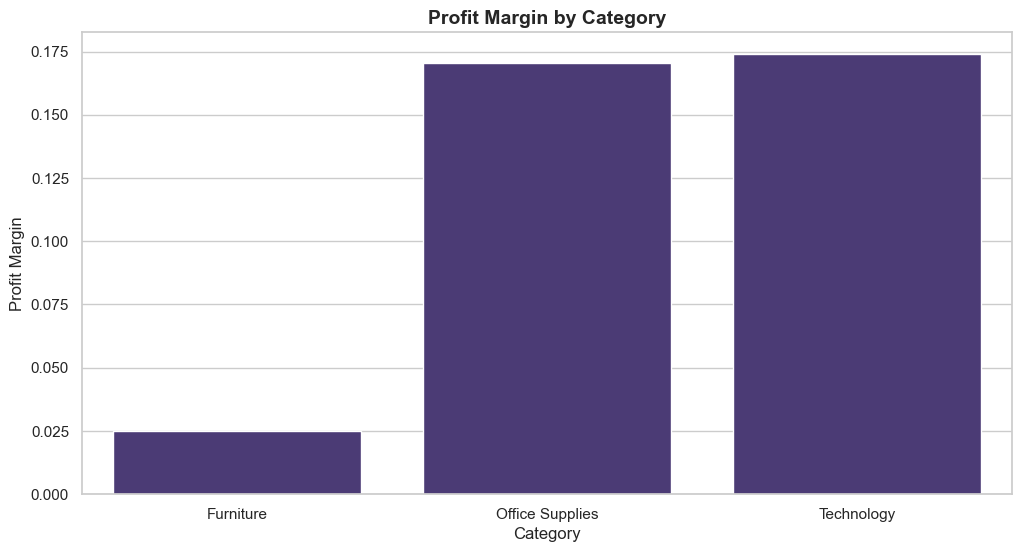

In [41]:
category_perf = df.groupby('Category')[['Sales','Profit']].sum()
category_perf['Profit_Margin'] = category_perf['Profit'] / category_perf['Sales']

sns.barplot(x=category_perf.index, y=category_perf['Profit_Margin'])
plt.title("Profit Margin by Category", fontsize=14, weight='bold')
plt.ylabel("Profit Margin")
plt.show()

**Insight:**  
Although some categories generate high total sales, their profit margins are comparatively lower. This suggests potential inefficiencies in pricing strategies or cost structures, indicating opportunities for margin optimization.

**Recommendation:**  
Focus on optimizing pricing and discount strategies in low-margin categories to improve overall profitability.

# Executive Summary
### Key Findings  
- Technology and Office Supplies are the primary revenue-driving categories  
- Profitability is concentrated in a few regions and states, indicating uneven performance  
- High discount levels are negatively impacting profit margins  
- Sales exhibit strong seasonal patterns with peak demand in specific months  

### Business Recommendations  
- Optimize discount strategies to protect and improve profit margins  
- Focus marketing and inventory efforts on high-performing regions  
- Reassess low-margin product categories to improve efficiency  
- Align inventory planning and promotions with seasonal demand trends  

### Conclusion  
This analysis highlights critical opportunities to enhance profitability and drive growth through data-driven decision-making. By optimizing pricing, regional strategies, and product focus, the business can improve both revenue and operational efficiency.
### 🏁 Strategic Recommendations
* **Focus on 'Hero' Products:** While Phones have high sales, **Copiers** are our most profitable items. We should prioritize Copier sales to maximize margins.
* **Fix the Furniture Gap:** The Furniture category is "bleeding" profit. We need to reduce discounts in this segment immediately to return to profitability.
* **Regional Strategy:** The **West Region** is our top performer. We should apply their sales model to the **Central Region**, which currently has the lowest profit margins.

# Technical Environment
***Libraries***
- pandas
- seaborn
- sqlite 3

In [44]:
df.to_csv("cleaned_data.csv")